# ক্লাসিফায়ারের অনিশ্চয়তা (Classifier Uncertainty)**গল্প: আমরা কতটা নিশ্চিত?**কল্পনা করো তুমি একজন শিক্ষক। তুমি পরীক্ষার খাতা দেখে বলো: 'আমি 99% নিশ্চিত যে এই ছাত্রটি A+ পাবে।' আরেকটি খাতা দেখে বলো: 'আমি মাত্র 51% নিশ্চিত যে এটি পাস করবে।'দুটি ভবিষ্যদ্বাণীই 'পাস' বললেও প্রথমটিতে তুমি অনেক বেশি নিশ্চিত! মেশিন লার্নিং মডেলও তাদের ভবিষ্যদ্বাণীর সাথে 'confidence' (আত্মবিশ্বাস) জানাতে পারে। একে বলে **অনিশ্চয়তা (Uncertainty)**।

## আমরা কী শিখব?1. predict_proba (probability আউটপুট)2. decision_function (সিদ্ধান্তের দূরত্ব)3. KNN-এর অনিশ্চয়তা4. Decision Tree-এর অনিশ্চয়তা5. Random Forest-এর অনিশ্চয়তা6. LogisticRegression-এর অনিশ্চয়তা

## প্রথমে লাইব্রেরি ইম্পোর্ট করি

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import train_test_split
print('লাইব্রেরি ইম্পোর্ট সফল হয়েছে!')

লাইব্রেরি ইম্পোর্ট সফল হয়েছে!


## ডেটা তৈরি করিmake_classification দিয়ে 2টি feature-এর ডেটা তৈরি করি।

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2463 (\N{BENGALI LETTER TTA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2488 (\N{BENGALI LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: Use

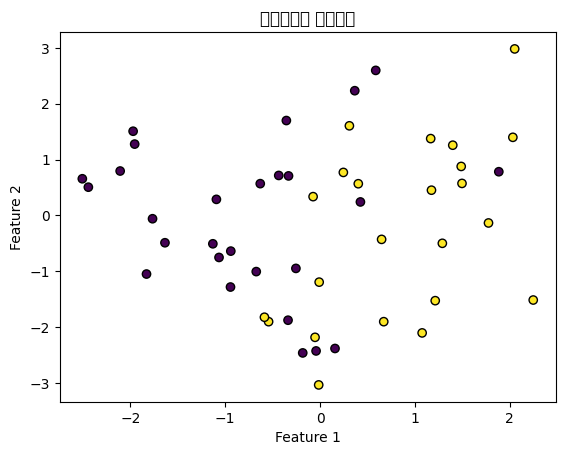

In [2]:
X, y = make_classification(n_samples=200, n_features=2,
                           n_informative=2, n_redundant=0,
                           random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k')
plt.title('টেস্ট ডেটা')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## LogisticRegression-এর অনিশ্চয়তাLogisticRegression-এ predict_proba() প্রতিটি ক্লাসের probability দেয়। decision_function() সিদ্ধান্তের দূরত্ব (distance from decision boundary) দেয়।

In [3]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
probs = logreg.predict_proba(X_test)
decisions = logreg.decision_function(X_test)
print('প্রথম 5 টেস্ট নমুনার জন্য:')
for i in range(5):
    max_prob = np.max(probs[i])
    pred_class = np.argmax(probs[i])
    true_class = y_test[i]
    print('নমুনা {}: pred={}, true={}, prob={:.3f}, decision={:.3f}'.format(
        i, pred_class, true_class, max_prob, decisions[i]))

প্রথম 5 টেস্ট নমুনার জন্য:
নমুনা 0: pred=1, true=1, prob=0.977, decision=3.750
নমুনা 1: pred=1, true=0, prob=0.588, decision=0.355
নমুনা 2: pred=1, true=1, prob=0.810, decision=1.448
নমুনা 3: pred=1, true=1, prob=0.678, decision=0.746
নমুনা 4: pred=0, true=1, prob=0.552, decision=-0.210


## KNN-এর অনিশ্চয়তাKNeighborsClassifier-এ predict_proba() k প্রতিবেশীর মধ্যে কতজন একই ক্লাসে ভোট দিয়েছে তার অনুপাত দেয়।

In [4]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
probs_knn = knn.predict_proba(X_test)
print('KNN-এর probability (প্রথম 5 নমুনা):')
print(probs_knn[:5])
for i in range(5):
    max_prob = np.max(probs_knn[i])
    print('নমুনা {}: probability={:.3f}'.format(i, max_prob))

KNN-এর probability (প্রথম 5 নমুনা):
[[0.  1. ]
 [0.4 0.6]
 [0.  1. ]
 [0.  1. ]
 [0.2 0.8]]
নমুনা 0: probability=1.000
নমুনা 1: probability=0.600
নমুনা 2: probability=1.000
নমুনা 3: probability=1.000
নমুনা 4: probability=0.800


## Decision Tree-এর uncertaintyDecisionTreeClassifier-এর predict_proba() প্রতিটি leaf node-তে ক্লাসের অনুপাত দেয়।

In [5]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
probs_tree = tree.predict_proba(X_test)
print('Decision Tree-এর probability (প্রথম 5 নমুনা):')
for i in range(5):
    max_prob = np.max(probs_tree[i])
    pred = np.argmax(probs_tree[i])
    print('নমুনা {}: pred={}, prob={:.3f}'.format(i, pred, max_prob))

Decision Tree-এর probability (প্রথম 5 নমুনা):
নমুনা 0: pred=0, prob=1.000
নমুনা 1: pred=1, prob=0.900
নমুনা 2: pred=1, prob=0.900
নমুনা 3: pred=1, prob=0.900
নমুনা 4: pred=1, prob=0.900


## Random Forest-এর uncertaintyRandom Forest সব গাছের predict_proba-র গড় নেয়, যা বেশি নির্ভরযোগ্য!

In [6]:
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)
probs_forest = forest.predict_proba(X_test)
print('Random Forest-এর probability (প্রথম 5 নমুনা):')
for i in range(5):
    max_prob = np.max(probs_forest[i])
    pred = np.argmax(probs_forest[i])
    print('নমুনা {}: pred={}, prob={:.3f}'.format(i, pred, max_prob))

Random Forest-এর probability (প্রথম 5 নমুনা):
নমুনা 0: pred=1, prob=0.610
নমুনা 1: pred=1, prob=0.650
নমুনা 2: pred=1, prob=0.930
নমুনা 3: pred=1, prob=0.990
নমুনা 4: pred=1, prob=0.750


## Uncertainty ভিজুয়ালাইজেশনDecision boundary-র কাছাকাছি পয়েন্টগুলোর uncertainty বেশি (probability 0.5-এর কাছাকাছি) হয়।

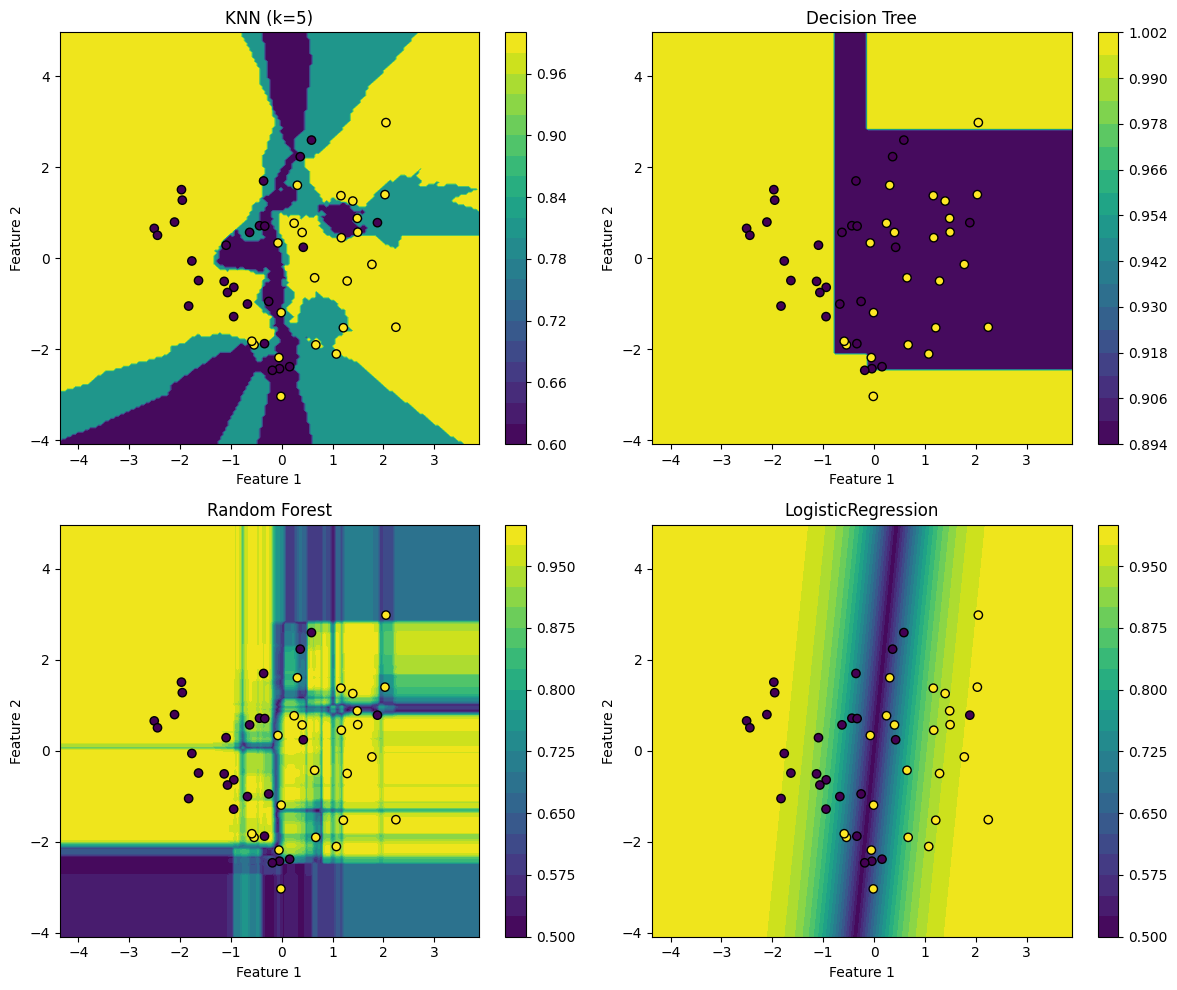

হলুদ রঙ = বেশি confident, গাঢ় = কম confident


In [7]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models = [
    ('KNN (k=5)', knn),
    ('Decision Tree', tree),
    ('Random Forest', forest),
    ('LogisticRegression', logreg)
]
for i, (name, model) in enumerate(models):
    ax = axes[i // 2, i % 2]
    Z_probs = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
    Z_conf = np.max(Z_probs, axis=1)
    Z_conf = Z_conf.reshape(xx.shape)
    contour = ax.contourf(xx, yy, Z_conf, levels=20, cmap='viridis')
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k')
    ax.set_title(name)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    plt.colorbar(contour, ax=ax)
plt.tight_layout()
plt.show()
print('হলুদ রঙ = বেশি confident, গাঢ় = কম confident')

## Iris ডেটাতে Uncertainty তুলনাIris ডেটাসেটে চারটি মডেলের uncertainty তুলনা করি।

In [8]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_iris, y_iris, random_state=42)
models_iris = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'LogisticRegression': LogisticRegression()
}
for name, model in models_iris.items():
    model.fit(Xi_train, yi_train)
    probs = model.predict_proba(Xi_test)
    confidences = np.max(probs, axis=1)
    print('{}: mean confidence={:.3f}, min confidence={:.3f}'.format(
        name, np.mean(confidences), np.min(confidences)))

KNN: mean confidence=0.963, min confidence=0.600
Decision Tree: mean confidence=0.978, min confidence=0.500
Random Forest: mean confidence=0.980, min confidence=0.880
LogisticRegression: mean confidence=0.903, min confidence=0.600


## সারসংক্ষেপ| পদ্ধতি | বর্ণনা | মডেল |
|--------|--------|------|
| predict_proba | প্রতিটি ক্লাসের probability | KNN, Tree, Forest, Logistic |
| decision_function | সিদ্ধান্ত সীমানা থেকে দূরত্ব | Logistic, SVM |
Uncertainty বোঝা গুরুত্বপূর্ণ কারণ:- কম confidence-এর ভবিষ্যদ্বাণী এড়ানো যায়- মডেল কখন ভুল করে তা বোঝা যায়- সিদ্ধান্ত নিতে সাহায্য করে (যেমন ডাক্তারি রোগ নির্ণয়)